In [3]:
# Metodo delle differenze finite 
import numpy as np 
import matplotlib.pyplot as plt  
import scipy.linalg as la


## approssimazione numerica di una derivata (continua) come differenze tra punti discreti

def exact_sol_1(x):
    return x**2 * (x - 1)**2

def exact_solution_2(x):
    return np.cos(np.pi * x)

def f_func_1(x):
    return x**4 - 2*x**3 + 13*x**2 - 12*x + 2

def f_func_2(x):
    return (np.pi**2 + 1) * np.cos(np.pi * x)


In [49]:
# Metodo delle differenze finite   2nd method 
import numpy as np 
import matplotlib.pyplot as plt  
import scipy.linalg as la


def exact_sol_1(x):
    return x**2 * (x - 1)**2

def exact_sol_2(x):
    return np.cos(np.pi * x)

## F = f(x) = u''(x) + u(x)  !!!!!!!

def f_func_1(x):
    return 2*(x-1)**2 + 8*x*(x-1) + 2*x**2 + x**2*(x-1)**2  

def f_func_2(x):
    return (np.pi**2 + 1) * np.cos(np.pi * x)


In [72]:
def finite_difference(n, f_func):
    h = 1 / (n - 1)
    x = np.linspace(0, 1, n)

# matrx A_ coeff d''
    A = 2 * np.diag(np.ones(n)) - np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), - 1)
    A[0, 0] = A[-1, -1] = 1  # neuman ai bordi
    A = A/ h**2

# matrix M : Ucoeff 
    M = np.eye(n)
    M[0, 0] = M[-1, -1] = 0.5

    A += M                      

    F = np.zeros((n, 1))        ### calcolo il valore della funzione per ogni x
    for i in range(n):
        F[i] = f_func(x[i])
        
    F = M@F                     #mi serve per riscalare il sistema : assegnare i coeff alla funzione

    U = np.linalg.solve(A, F) # AU = F

    return x, U


In [7]:
n = 5
A = 2 * np.diag(np.ones(n)) - np.diag(np.ones(n - 1), 1) - np.diag(np.ones(n - 1), - 1)
A[0, 0] = A[-1, -1] = 1  

### C'è IL MENO DELLA DIFFERENZIALE SECONDA d2u/dx2
A

array([[ 1., -1.,  0.,  0.,  0.],
       [-1.,  2., -1.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.],
       [ 0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0., -1.,  1.]])

0.10129314277631028
0.011745288225750938
0.07418350361281487
0.002921955460578607
0.0673857871628634
0.0007295948612500158
0.06568508447491249
0.00018234290094687466
0.06525982913532564
4.5582237857777486e-05
0.06515351032009845
1.1395341630304756e-05
0.06512693030505902
2.848822402201634e-06
0.06512028528179811
7.122090361910693e-07


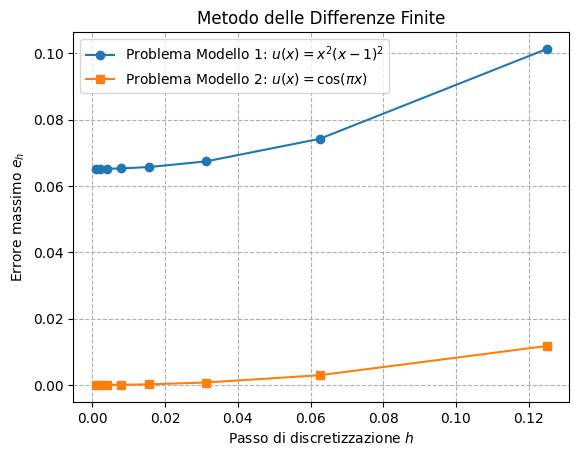

In [73]:
hs = [1/8, 1/16, 1/32, 1/64, 1/128, 1/256, 1/512, 1/1024]
errors_1 = []
errors_2 = []
exact_sol1= []
exact_sol2 = []

for h in hs:
    n = int(1/h + 1 )


# 1st function
    x, U_num_1 = finite_difference(n, f_func_1) # mi restituisce per ogni punto il valore dell'app numerica 
    U_exact_1 = np.zeros((n, 1))
    for i in range(n):
        U_exact_1[i] = exact_sol_1(x[i])
    error_1 = np.max(np.abs(U_exact_1 - U_num_1))   # differenza degli array
    print(error_1)
    errors_1.append(error_1)

# 2nd function
    x, U_num_2 = finite_difference(n, f_func_2)
    U_exact_2 = np.zeros((n, 1))
    for i in range(n):
        U_exact_2[i] = exact_sol_2(x[i])
    error_2 = np.max(np.abs(U_exact_2 - U_num_2))
    print(error_2)
    errors_2.append(error_2)

plt.plot(hs, errors_1, 'o-', label='Problema Modello 1: $u(x) = x^2(x - 1)^2$')
plt.plot(hs, errors_2, 's-', label='Problema Modello 2: $u(x) = \cos(\pi x)$')
plt.xlabel('Passo di discretizzazione $h$')
plt.ylabel('Errore massimo $e_h$')
plt.title('Metodo delle Differenze Finite')
plt.legend()
plt.grid(True, ls="--")

Exact sol 1: [[0.00000000e+00]
 [9.51812581e-07]
 [3.79981066e-06]
 ...
 [3.79981066e-06]
 [9.51812581e-07]
 [0.00000000e+00]]
Exact sol 2: [[ 1.        ]
 [ 0.99999529]
 [ 0.99998118]
 ...
 [-0.99998118]
 [-0.99999529]
 [-1.        ]]


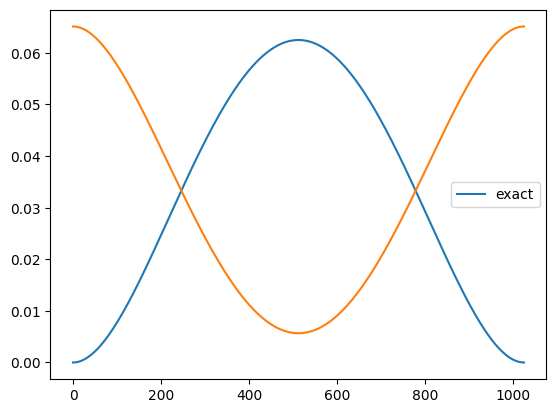

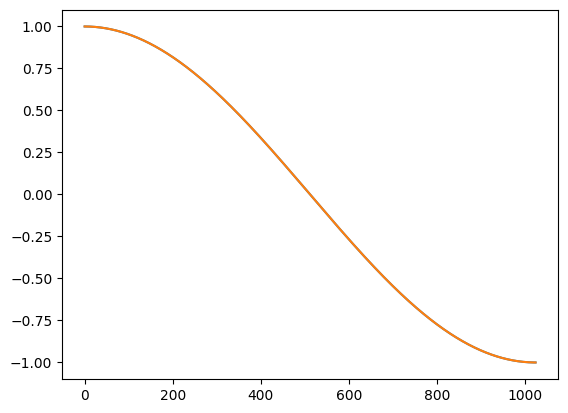

In [74]:
print ("Exact sol 1:", U_exact_1)
print ("Exact sol 2:", U_exact_2)

plt.plot(U_exact_1, label="exact")
plt.plot(U_num_1)
plt.legend()
plt.show()
plt.plot(U_exact_2)
plt.plot(U_num_2)
plt.show()